# Notebook 01: Dataset Validation

### Purpose
- Establishes that the experiment data is trustworthy before any outcome analysis.

### Objectives
- Verify arm sizes are consistent with random assignment via a Sample Ratio Mismatch test.
- Confirm covariate balance across arms as evidence that randomization succeeded.
- Characterize baseline outcome rates and the spend distribution to orient the analysis that follows.

## 1. Get, load, and verify dataset

In [1]:
import warnings
from pathlib import Path
import urllib.request

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chisquare

In [2]:
data_path = Path("../data/raw/hillstrom.csv")

if not data_path.exists():
    url = "http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"
    data_path.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, data_path)
    print("Downloaded.")
else:
    print(f"Data already exists ({data_path.stat().st_size / 1024:.0f} KB).")

Data already exists (3872 KB).


In [3]:
hillstrom_df = pd.read_csv(data_path)

display(hillstrom_df.head(), hillstrom_df.tail())

display(hillstrom_df.describe())

display(hillstrom_df.info())

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web,Mens E-Mail,0,0,0.0
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone,Mens E-Mail,0,0,0.0
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone,Mens E-Mail,0,0,0.0
63998,1,5) $500 - $750,552.94,1,0,Surburban,1,Multichannel,Womens E-Mail,0,0,0.0
63999,1,4) $350 - $500,472.82,0,1,Surburban,0,Web,Mens E-Mail,0,0,0.0


,recency,history,mens,womens,newbie,visit,conversion,spend
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781,0.009031,1.050908
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890,0.094604,15.036448
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000,1.000000,499.000000


<class 'pandas.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  str    
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  str    
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  str    
 8   segment          64000 non-null  str    
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), str(4)
memory usage: 5.9 MB


None

In [4]:
print(f"Duplicate rows: {hillstrom_df.duplicated().sum()}")

Duplicate rows: 6562


In [5]:
for col in hillstrom_df.select_dtypes(include="str").columns:
    print(f"{col}\n{hillstrom_df[col].value_counts()}\n")

history_segment
history_segment
1) $0 - $100        22970
2) $100 - $200      14254
3) $200 - $350      12289
4) $350 - $500       6409
5) $500 - $750       4911
6) $750 - $1,000     1859
7) $1,000 +          1308
Name: count, dtype: int64

zip_code
zip_code
Surburban    28776
Urban        25661
Rural         9563
Name: count, dtype: int64

channel
channel
Web             28217
Phone           28021
Multichannel     7762
Name: count, dtype: int64

segment
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64



In [6]:
con = duckdb.connect()
con.execute("CREATE TABLE hillstrom AS SELECT * FROM hillstrom_df")

display(con.execute("SELECT COUNT(*) AS n_rows FROM hillstrom").df())

con.execute("SELECT * FROM hillstrom LIMIT 5").df()

,n_rows
0,64000


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


### Logical consistency checks
- Every conversion should have a visit (conversion=1 implies visit=1)
- Every non-zero spend should have a conversion (spend > 0 implies conversion=1)

In [7]:
con.execute("""
    SELECT
        SUM(CASE WHEN conversion = 1 AND visit = 0 THEN 1 ELSE 0 END) AS conversion_without_visit,
        SUM(CASE WHEN spend > 0 AND conversion = 0 THEN 1 ELSE 0 END) AS spend_without_conversion
    FROM hillstrom
""").df()

,conversion_without_visit,spend_without_conversion
0,0.0,0.0


## 2. Exploration

### SRM

In [8]:
arm_counts_df = con.execute("""
    SELECT segment, COUNT(*) AS n
    FROM hillstrom
    GROUP BY segment
    """).df()

total = arm_counts_df["n"].sum()
n_arms = len(arm_counts_df)
observed = arm_counts_df["n"].values
expected = [total / n_arms] * n_arms

stat, p_value = chisquare(observed, f_exp=expected)
print(f"Chi-squared: {stat:.4f}, p-value: {p_value:.4f}")

threshold = 0.01
srm_detected = p_value < threshold
if srm_detected:
    warnings.warn("SRM detected - investigate before proceeding.")
else:
    print("No SRM detected - arm sizes consistent with random assignment.")

arm_counts_df["expected"] = expected
arm_counts_df["residual"] = arm_counts_df["n"] - arm_counts_df["expected"]
arm_counts_df["residual_pct"] = arm_counts_df["residual"] / arm_counts_df["expected"] * 100
arm_counts_df

Chi-squared: 0.2025, p-value: 0.9037
No SRM detected - arm sizes consistent with random assignment.


,segment,n,expected,residual,residual_pct
0,Womens E-Mail,21387,21333.333333,53.666667,0.251563
1,Mens E-Mail,21307,21333.333333,-26.333333,-0.123437
2,No E-Mail,21306,21333.333333,-27.333333,-0.128125


### Baseline rates (visit rate, conversion rate, mean spend) per arm


In [9]:
con.execute("""
    SELECT
        segment,
        COUNT(*) AS n,
        ROUND(AVG(visit), 4) AS visit_rate,
        ROUND(AVG(conversion), 4) AS conversion_rate,
        ROUND(AVG(spend), 4) AS mean_spend
    FROM hillstrom
    GROUP BY segment
    ORDER BY segment
""").df()

,segment,n,visit_rate,conversion_rate,mean_spend
0,Mens E-Mail,21307,0.1828,0.0125,1.4226
1,No E-Mail,21306,0.1062,0.0057,0.6528
2,Womens E-Mail,21387,0.1514,0.0088,1.0772


### Check covariate balance: mean recency, channel distribution, newbie proportion, history by arm

In [10]:
# Numeric covariates and newbie proportion
con.execute("""
    SELECT
        segment,
        ROUND(AVG(recency), 2) AS mean_recency,
        ROUND(AVG(history), 2) AS mean_history,
        ROUND(AVG(newbie), 4) AS newbie_rate,
        ROUND(AVG(mens), 4) AS mens_rate,
        ROUND(AVG(womens), 4) AS womens_rate
    FROM hillstrom
    GROUP BY segment
    ORDER BY segment
""").df()

,segment,mean_recency,mean_history,newbie_rate,mens_rate,womens_rate
0,Mens E-Mail,5.77,242.84,0.5015,0.5509,0.5514
1,No E-Mail,5.75,240.88,0.5020,0.5532,0.5476
2,Womens E-Mail,5.77,242.54,0.5032,0.5489,0.5501


In [11]:
# Channel distribution by arm
con.execute("""
    SELECT
        segment,
        channel,
        COUNT(*) AS n,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY segment), 2) AS pct
    FROM hillstrom
    GROUP BY segment, channel
    ORDER BY segment, channel
""").df()


,segment,channel,n,pct
0,Mens E-Mail,Multichannel,2577,12.09
1,Mens E-Mail,Phone,9240,43.37
2,Mens E-Mail,Web,9490,44.54
3,No E-Mail,Multichannel,2606,12.23
4,No E-Mail,Phone,9327,43.78
5,No E-Mail,Web,9373,43.99
6,Womens E-Mail,Multichannel,2579,12.06
7,Womens E-Mail,Phone,9454,44.20
8,Womens E-Mail,Web,9354,43.74


In [12]:
# Zip code distribution by arm
con.execute("""
    SELECT
        segment,
        zip_code,
        COUNT(*) AS n,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY segment), 2) AS pct
    FROM hillstrom
    GROUP BY segment, zip_code
    ORDER BY segment, zip_code
""").df()


,segment,zip_code,n,pct
0,Mens E-Mail,Rural,3243,15.22
1,Mens E-Mail,Surburban,9501,44.59
2,Mens E-Mail,Urban,8563,40.19
3,No E-Mail,Rural,3139,14.73
4,No E-Mail,Surburban,9625,45.18
5,No E-Mail,Urban,8542,40.09
6,Womens E-Mail,Rural,3181,14.87
7,Womens E-Mail,Surburban,9650,45.12
8,Womens E-Mail,Urban,8556,40.01


In [13]:
# SMD check for covariate balance

def smd(group1, group2):
    """Calculate standardized mean difference between two groups."""
    pooled_sd = np.sqrt((group1.var() + group2.var()) / 2)
    smd_value = (group1.mean() - group2.mean()) / pooled_sd
    return smd_value

covariates = ["recency", "history", "newbie", "mens", "womens"]
control = hillstrom_df[hillstrom_df["segment"] == "No E-Mail"]

any_flagged = False
for arm in ["Mens E-Mail", "Womens E-Mail"]:
    group = hillstrom_df[hillstrom_df["segment"] == arm]
    for col in covariates:
        smd_value = smd(control[col], group[col])
        if smd_value >= 0.1:
            warnings.warn(f"Imbalance: {col} {arm} vs Control (SMD={smd_value:.4f})")
            any_flagged = True
if not any_flagged:
        print("All covariates balanced (SMD < 0.1).")

All covariates balanced (SMD < 0.1).


### Distribution of spend

,pct_zero,mean_spend,median_spend,std_spend,max_spend
0,99.1,1.05,0.0,15.04,499.0


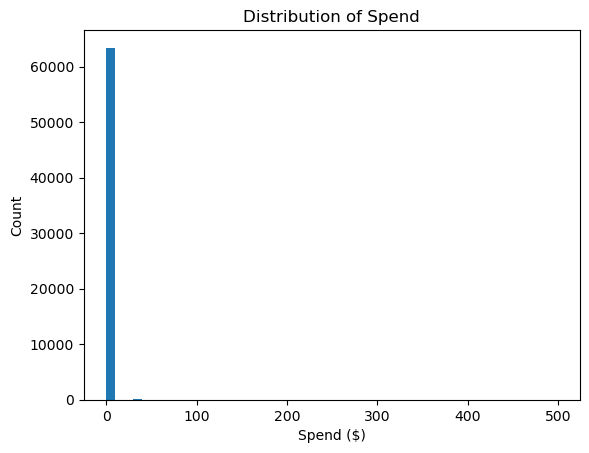

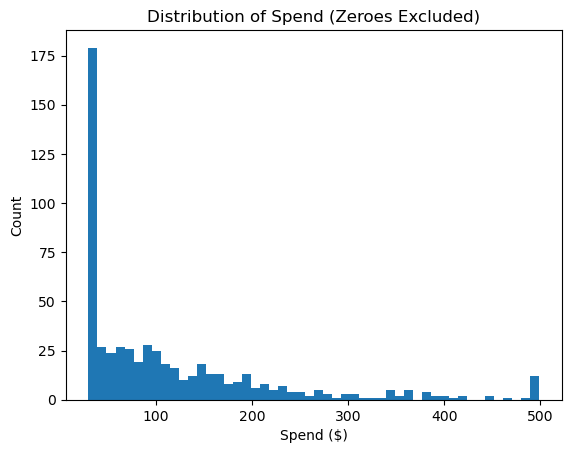

In [14]:
# Summary stats highlighting zero-inflation and skew
display(con.execute("""
    SELECT
        ROUND(AVG(CAST(spend = 0 AS INTEGER)) * 100, 1) AS pct_zero,
        ROUND(AVG(spend), 2) AS mean_spend,
        ROUND(MEDIAN(spend), 2) AS median_spend,
        ROUND(STDDEV(spend), 2) AS std_spend,
        ROUND(MAX(spend), 2) AS max_spend
    FROM hillstrom
    """).df())

plt.hist(hillstrom_df["spend"], bins=50)
plt.xlabel("Spend ($)")
plt.ylabel("Count")
plt.title("Distribution of Spend")
plt.show()

plt.hist(hillstrom_df[hillstrom_df["spend"] > 0]["spend"], bins=50)
plt.xlabel("Spend ($)")
plt.ylabel("Count")
plt.title("Distribution of Spend (Zeroes Excluded)")
plt.show()

## Summary
- No SRM found (p-value = 0.90), arm sizes are as expected
- Covariates are balanced and randomization held (SMD < 0.1)
- The men's email had the highest rate of visits, conversions, and spending
- Spend is heavily zero inflated (85% zeroes) with a long right tail
- No nulls, no logical violations.
- **Data is verfiied and ready for hypothesis testing**